In [1]:
import pandas as pd

In [2]:
# Linear Regression
linear_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [5.082782],
    "MSE": [42.967394],
    "RMSE": [6.554952],
    "R2": [0.806003]
})

# Random Forest
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [1.549929],
    "MSE": [4.390979],
    "RMSE": [2.095466],
    "R2": [0.980175]
})

# XGBoost
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [0.5080],
    "MSE": [0.4539],
    "RMSE": [0.6735],
    "R2": [0.9980]
})

model_comparison = pd.concat(
    [linear_results, rf_results, xgb_results],
    ignore_index=True
)

display(model_comparison)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,5.082782,42.967394,6.554952,0.806003
1,Random Forest,1.549929,4.390979,2.095466,0.980175
2,XGBoost,0.508000,0.453900,0.673500,0.998000


In [3]:
model_comparison.to_csv(
    "../data/processed/classical_model_comparison.csv",
    index=False
)

print("Classical model comparison saved successfully.")

Classical model comparison saved successfully.


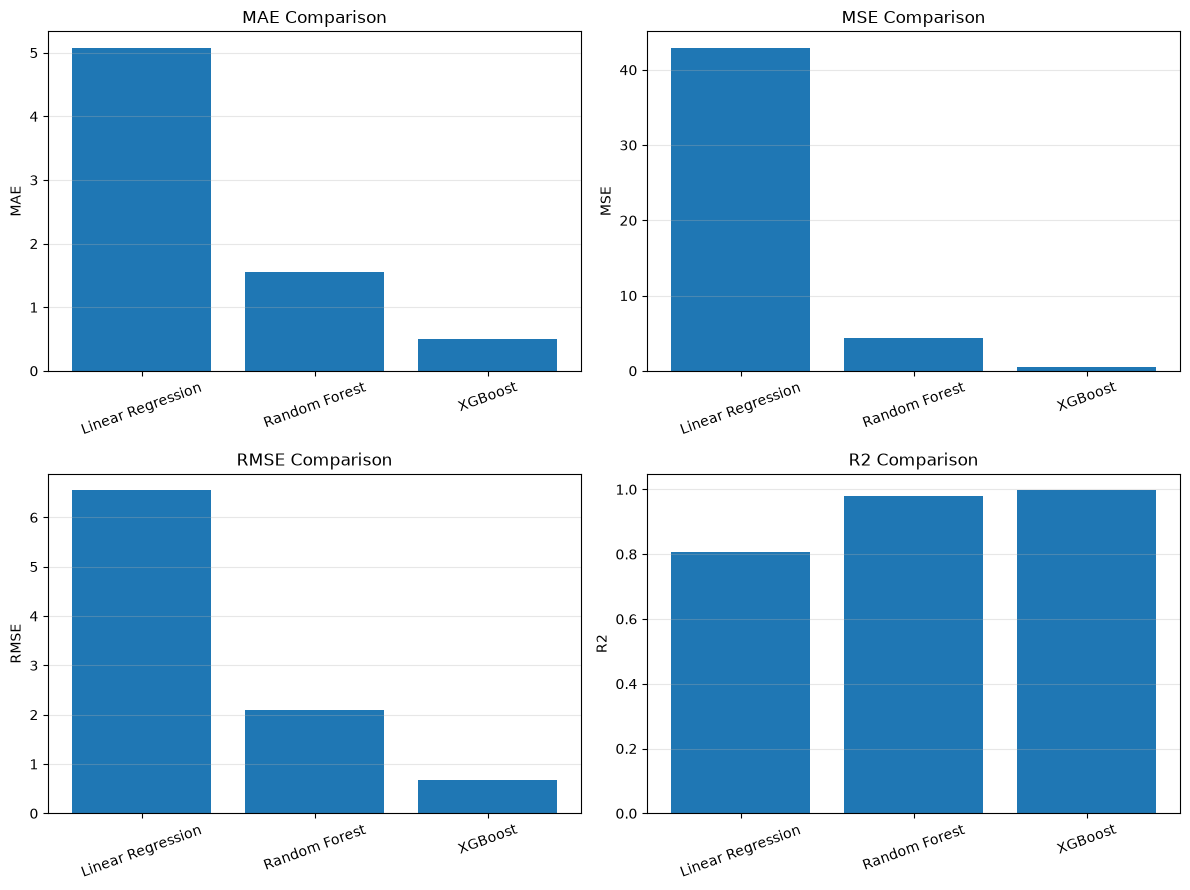

In [4]:
import matplotlib.pyplot as plt

metrics = ["MAE", "MSE", "RMSE", "R2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    ax.bar(
        model_comparison["Model"],
        model_comparison[metric]
    )

    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
fig.savefig(
    "../data/processed/classical_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Classical model comparison graph saved successfully.")

Classical model comparison graph saved successfully.


In [6]:
lstm_results = pd.read_csv(
    "../data/processed/lstm_results.csv"
)

gru_results = pd.read_csv(
    "../data/processed/gru_results.csv"
)

lstm_results["Model"] = "LSTM"
gru_results["Model"] = "GRU"

sequence_comparison = pd.concat(
    [lstm_results, gru_results],
    ignore_index=True
)

sequence_comparison = sequence_comparison[
    ["Model", "sequence_length", "MAE", "MSE", "RMSE", "R2"]
]

display(sequence_comparison)

,Model,sequence_length,MAE,MSE,RMSE,R2
0,LSTM,5,0.808700,1.437600,1.199000,0.993400
1,LSTM,10,0.711984,1.171819,1.082506,0.994685
2,LSTM,20,1.058678,2.733736,1.653401,0.987829
3,LSTM,30,1.305166,4.578792,2.139811,0.980026
4,GRU,5,0.854308,2.041993,1.428983,0.990620
5,GRU,10,1.099531,2.758420,1.660849,0.987488
6,GRU,20,0.938461,2.616108,1.617439,0.988353
7,GRU,30,1.127343,3.446014,1.856344,0.984967


In [7]:
sequence_comparison.to_csv(
    "../data/processed/lstm_gru_sequence_comparison.csv",
    index=False
)

print("LSTM + GRU sequence comparison saved successfully.")

LSTM + GRU sequence comparison saved successfully.


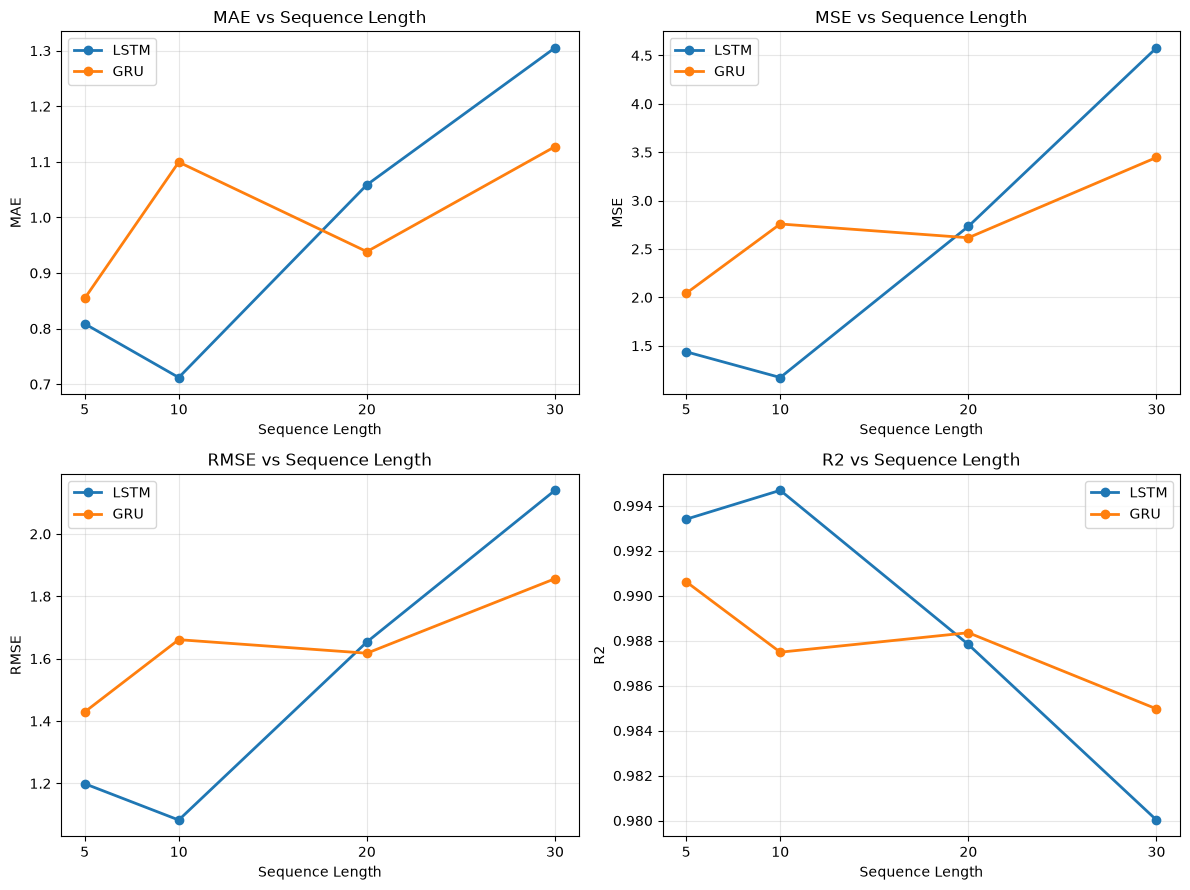

In [8]:
import matplotlib.pyplot as plt

metrics = ["MAE", "MSE", "RMSE", "R2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):

    for model in ["LSTM", "GRU"]:

        model_data = sequence_comparison[
            sequence_comparison["Model"] == model
        ]

        ax.plot(
            model_data["sequence_length"],
            model_data[metric],
            marker="o",
            linewidth=2,
            label=model
        )

    ax.set_title(f"{metric} vs Sequence Length")
    ax.set_xlabel("Sequence Length")
    ax.set_ylabel(metric)
    ax.set_xticks([5, 10, 20, 30])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()

fig.savefig(
    "../data/processed/lstm_gru_sequence_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Overall Model Results

The keyboard productivity pipeline was evaluated using Linear Regression, Random Forest, XGBoost, LSTM, and GRU models.

The classical models used the six selected behavioral features:

- DU.key1.key1_median
- DU.key1.key2_median
- unique_key1_count
- unique_transition_count
- consecutive_key1_repetition_rate
- backspace_rate

Linear Regression provided a baseline model, followed by Random Forest and XGBoost. The sequence models, LSTM and GRU, were evaluated separately using sequence lengths of 5, 10, 20, and 30.

### Classical Models

Linear Regression achieved an MAE of 5.082782 and R² of 0.806003.

Random Forest achieved an MAE of 1.549929 and R² of 0.980175.

XGBoost achieved a mean MAE of approximately 0.5080 and mean R² of approximately 0.9980 across its five group-based folds.

### Sequence Models

For LSTM, sequence length 10 produced the lowest recorded MAE (0.711984) and highest R² (0.994685) among the tested LSTM configurations.

For GRU, sequence length 5 produced the lowest recorded MAE (0.854308) and highest R² (0.990620) among the tested GRU configurations.

The results show that increasing sequence length does not consistently improve performance.

## Important Limitations

The productivity score is a constructed target derived from the same six behavioral features used as model inputs. Therefore, high model performance primarily demonstrates how accurately the models reproduce the constructed productivity score and does not independently validate real-world employee productivity.

The 5th–95th percentile normalization used to construct the productivity score was calculated using the complete dataset before model splitting. This should be considered when interpreting the evaluation results.

The direction assigned to the timing features is also a design assumption because the available dataset documentation does not establish the behavioral meaning of every timing variable.

The sequence models use participant-session grouped train-test splitting, but the validation split used during neural-network training was not group-aware.

In [9]:
import os

processed_path = "../data/processed"

for file in sorted(os.listdir(processed_path)):
    print(file)

classical_model_comparison.csv
classical_model_comparison.png
feature_importance_comparison.png
gru_results.csv
keyboard_features.csv
keyboard_productivity_scores.csv
keyboard_reduced_productivity_dataset.csv
lstm_gru_sequence_comparison.csv
lstm_gru_sequence_comparison.png
lstm_results.csv
lstm_vs_gru_comparison.csv
random_forest_feature_importance.csv
random_forest_results.csv
rf_vs_xgboost_feature_importance.csv
xgboost_feature_importance.csv
xgboost_fold_results.csv


In [10]:
print("===== CLASSICAL MODELS =====")
display(
    pd.read_csv("../data/processed/classical_model_comparison.csv")
)

print("\n===== LSTM RESULTS =====")
display(
    pd.read_csv("../data/processed/lstm_results.csv")
)

print("\n===== GRU RESULTS =====")
display(
    pd.read_csv("../data/processed/gru_results.csv")
)

print("\n===== LSTM + GRU COMPARISON =====")
display(
    pd.read_csv("../data/processed/lstm_vs_gru_comparison.csv")
)

===== CLASSICAL MODELS =====


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,5.082782,42.967394,6.554952,0.806003
1,Random Forest,1.549929,4.390979,2.095466,0.980175
2,XGBoost,0.508000,0.453900,0.673500,0.998000



===== LSTM RESULTS =====


,sequence_length,MAE,MSE,RMSE,R2
0,5,0.808700,1.437600,1.199000,0.993400
1,10,0.711984,1.171819,1.082506,0.994685
2,20,1.058678,2.733736,1.653401,0.987829
3,30,1.305166,4.578792,2.139811,0.980026



===== GRU RESULTS =====


,sequence_length,MAE,MSE,RMSE,R2
0,5,0.854308,2.041993,1.428983,0.990620
1,10,1.099531,2.758420,1.660849,0.987488
2,20,0.938461,2.616108,1.617439,0.988353
3,30,1.127343,3.446014,1.856344,0.984967



===== LSTM + GRU COMPARISON =====


,Model,sequence_length,MAE,MSE,RMSE,R2
0,LSTM,5,0.808700,1.437600,1.199000,0.993400
1,LSTM,10,0.711984,1.171819,1.082506,0.994685
2,LSTM,20,1.058678,2.733736,1.653401,0.987829
3,LSTM,30,1.305166,4.578792,2.139811,0.980026
4,GRU,5,0.854308,2.041993,1.428983,0.990620
5,GRU,10,1.099531,2.758420,1.660849,0.987488
6,GRU,20,0.938461,2.616108,1.617439,0.988353
7,GRU,30,1.127343,3.446014,1.856344,0.984967


In [11]:
import pandas as pd

# Load Random Forest feature importance
rf_importance = pd.read_csv(
    "../data/processed/random_forest_feature_importance.csv"
)

# Load XGBoost feature importance
xgb_importance = pd.read_csv(
    "../data/processed/xgboost_feature_importance.csv"
)

print("===== RANDOM FOREST FEATURE IMPORTANCE =====")
display(rf_importance)

print("\n===== XGBOOST FEATURE IMPORTANCE =====")
display(xgb_importance)

===== RANDOM FOREST FEATURE IMPORTANCE =====


,feature,importance
0,consecutive_key1_repetition_rate,0.412063
1,DU.key1.key1_median,0.159486
2,unique_key1_count,0.149125
3,backspace_rate,0.109670
4,DU.key1.key2_median,0.091081
5,unique_transition_count,0.078575



===== XGBOOST FEATURE IMPORTANCE =====


,feature,importance
0,consecutive_key1_repetition_rate,0.347606
1,backspace_rate,0.220193
2,unique_key1_count,0.132842
3,unique_transition_count,0.115663
4,DU.key1.key1_median,0.106103
5,DU.key1.key2_median,0.077593


In [12]:
import matplotlib.pyplot as plt

# Standardize the column names for plotting
rf_plot = rf_importance.copy()
xgb_plot = xgb_importance.copy()

print("Random Forest columns:", rf_plot.columns.tolist())
print("XGBoost columns:", xgb_plot.columns.tolist())

Random Forest columns: ['feature', 'importance']
XGBoost columns: ['feature', 'importance']


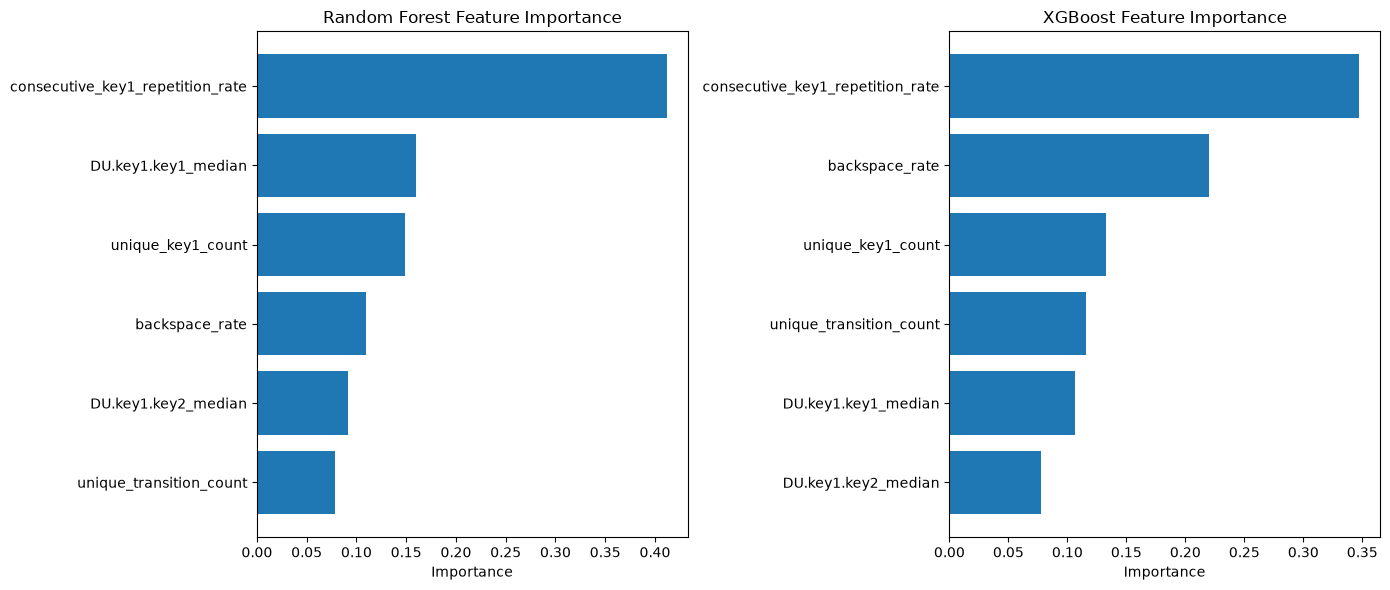

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_sorted = rf_importance.sort_values(
    by="importance",
    ascending=True
)

axes[0].barh(
    rf_sorted["feature"],
    rf_sorted["importance"]
)
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance")

# XGBoost
xgb_sorted = xgb_importance.sort_values(
    by="importance",
    ascending=True
)

axes[1].barh(
    xgb_sorted["feature"],
    xgb_sorted["importance"]
)
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()

fig.savefig(
    "../data/processed/feature_importance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Importance Analysis

Random Forest and XGBoost feature importance were examined to understand which keyboard behavioral features contributed most to reproducing the constructed productivity score.

The analysis focuses on six selected features:

* `DU.key1.key1_median`
* `DU.key1.key2_median`
* `unique_key1_count`
* `unique_transition_count`
* `consecutive_key1_repetition_rate`
* `backspace_rate`

Random Forest and XGBoost may assign different importance values because they learn relationships in different ways.

Feature importance indicates how a model uses features for prediction. It does not establish causation or prove that a particular typing behavior directly represents employee productivity.

**Limitation:** The target productivity score was constructed from these same behavioral features. Therefore, feature importance describes the model's reproduction of the designed score, not independently validated employee productivity.


In [14]:
print("Random Forest feature importance:")
display(
    rf_importance.sort_values(
        by="importance",
        ascending=False
    )
)

print("XGBoost feature importance:")
display(
    xgb_importance.sort_values(
        by="importance",
        ascending=False
    )
)

Random Forest feature importance:


,feature,importance
0,consecutive_key1_repetition_rate,0.412063
1,DU.key1.key1_median,0.159486
2,unique_key1_count,0.149125
3,backspace_rate,0.109670
4,DU.key1.key2_median,0.091081
5,unique_transition_count,0.078575


XGBoost feature importance:


,feature,importance
0,consecutive_key1_repetition_rate,0.347606
1,backspace_rate,0.220193
2,unique_key1_count,0.132842
3,unique_transition_count,0.115663
4,DU.key1.key1_median,0.106103
5,DU.key1.key2_median,0.077593


## Interpretation of Feature Importance

The Random Forest and XGBoost feature-importance results show that `consecutive_key1_repetition_rate` has the highest importance in both models, with values of 0.412063 and 0.347606, respectively.

`backspace_rate` has a higher importance in XGBoost (0.220193) than in Random Forest (0.109670). `unique_key1_count` contributes to both models, while `unique_transition_count` has a higher importance in XGBoost than in Random Forest.

The timing features `DU.key1.key1_median` and `DU.key1.key2_median` have lower importance values relative to the leading features in both models.

These values indicate how each trained model uses the selected features to reproduce the constructed productivity score. They should not be interpreted as causal effects or independent evidence of employee productivity.


In [15]:
import pandas as pd

# Load classical model comparison
model_comparison = pd.read_csv(
    "../data/processed/classical_model_comparison.csv"
)

# Load LSTM and GRU results
lstm_results = pd.read_csv(
    "../data/processed/lstm_results.csv"
)

gru_results = pd.read_csv(
    "../data/processed/gru_results.csv"
)

# Load feature importance
rf_importance = pd.read_csv(
    "../data/processed/random_forest_feature_importance.csv"
)

xgb_importance = pd.read_csv(
    "../data/processed/xgboost_feature_importance.csv"
)

print("All saved results loaded successfully!")

All saved results loaded successfully!


In [16]:
print("===== CLASSICAL MODELS =====")
display(model_comparison)

print("\n===== LSTM RESULTS =====")
display(lstm_results)

print("\n===== GRU RESULTS =====")
display(gru_results)

print("\n===== FEATURE IMPORTANCE =====")
display(rf_importance)
display(xgb_importance)

===== CLASSICAL MODELS =====


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,5.082782,42.967394,6.554952,0.806003
1,Random Forest,1.549929,4.390979,2.095466,0.980175
2,XGBoost,0.508000,0.453900,0.673500,0.998000



===== LSTM RESULTS =====


,sequence_length,MAE,MSE,RMSE,R2
0,5,0.808700,1.437600,1.199000,0.993400
1,10,0.711984,1.171819,1.082506,0.994685
2,20,1.058678,2.733736,1.653401,0.987829
3,30,1.305166,4.578792,2.139811,0.980026



===== GRU RESULTS =====


,sequence_length,MAE,MSE,RMSE,R2
0,5,0.854308,2.041993,1.428983,0.990620
1,10,1.099531,2.758420,1.660849,0.987488
2,20,0.938461,2.616108,1.617439,0.988353
3,30,1.127343,3.446014,1.856344,0.984967



===== FEATURE IMPORTANCE =====


,feature,importance
0,consecutive_key1_repetition_rate,0.412063
1,DU.key1.key1_median,0.159486
2,unique_key1_count,0.149125
3,backspace_rate,0.109670
4,DU.key1.key2_median,0.091081
5,unique_transition_count,0.078575


,feature,importance
0,consecutive_key1_repetition_rate,0.347606
1,backspace_rate,0.220193
2,unique_key1_count,0.132842
3,unique_transition_count,0.115663
4,DU.key1.key1_median,0.106103
5,DU.key1.key2_median,0.077593
